# ASSISTments 2012-2013

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = '2012-2013-data-with-predictions-4-final.csv' 
df = pd.read_csv(DATA_PATH, low_memory=False)

print('Dataset Shape:', df.shape)
display(df.head())


Dataset Shape: (6123270, 35)


,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,...,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,137792159,NaN,557460,61394,565736,341511,2012-09-28 15:11:27,2012-09-28 15:11:36.856,choose_1,1,...,9852,341511,NaN,she,0,137792159,0.361323,0.0,0.336529,0.000000
1,138083797,Rounding,365981,61394,573819,204043,2012-10-09 11:01:52,2012-10-09 11:02:13.182,algebra,1,...,21175,204043,NaN,74.29,0,138083797,0.361323,0.0,0.766925,0.000000
2,142332619,Multiplication and Division Integers,426415,61394,734130,247525,2013-03-07 10:53:20,2013-03-07 10:53:28.661,algebra,1,...,8645,247525,NaN,00,0,142332619,0.361323,0.0,0.766925,0.442968
3,145939397,Proportion,86686,61394,821352,48081,2013-08-20 19:54:56,2013-08-20 19:55:21.753,algebra,1,...,25728,46362,NaN,3.8,0,145939397,0.775000,0.0,0.766925,0.912281
4,137111284,NaN,399669,76592,557216,227869,2012-09-10 17:20:10,2012-09-10 17:24:56.579,choose_1,1,...,286578,227869,NaN,C (wr - 1)(wr + 1),0,137111284,0.361323,0.0,0.766925,0.000000


## Dataset Overview

In [3]:
display(df.describe(include='all').T)
print(df.dtypes)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem_log_id,6123270.0,NaN,NaN,NaN,141493235.36553,2693732.939682,136843143.0,139170529.5,141491634.5,143827249.5,146235670.0
skill,2630080,198,Equation Solving Two or Fewer Steps,192976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
problem_id,6123270.0,NaN,NaN,NaN,368567.484748,219542.086733,1.0,128403.0,416813.0,564403.0,767143.0
user_id,6123270.0,NaN,NaN,NaN,177049.180873,31724.314306,21421.0,171978.0,179167.0,197251.0,228213.0
assignment_id,6123270.0,NaN,NaN,NaN,677307.350689,94259.831126,181456.0,586357.0,678564.5,767232.0,833054.0
assistment_id,6123270.0,NaN,NaN,NaN,220282.488766,139351.944505,5.0,68837.25,239918.0,346683.0,492589.0
start_time,6123270,4672374,2012-09-07 11:45:21,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,6123270,6121336,2013-01-18 10:56:08.239,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
problem_type,6123270,6,algebra,3500688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original,6123270.0,NaN,NaN,NaN,0.95043,0.217056,0.0,1.0,1.0,1.0,1.0


problem_log_id                         int64
skill                                 object
problem_id                             int64
user_id                                int64
assignment_id                          int64
assistment_id                          int64
start_time                            object
end_time                              object
problem_type                          object
original                               int64
correct                              float64
bottom_hint                          float64
hint_count                             int64
actions                               object
attempt_count                          int64
ms_first_response                      int64
tutor_mode                            object
sequence_id                            int64
student_class_id                       int64
position                               int64
type                                  object
base_sequence_id                       int64
skill_id  

## Missing Values

In [4]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': 100 * df.isna().sum() / len(df)
}).sort_values('Missing %', ascending=False)

display(missing)

,Missing Count,Missing %
answer_id,6114995,99.864860
skill,3493190,57.047787
skill_id,3411457,55.712993
answer_text,346500,5.658741
bottom_hint,60348,0.985552
school_id,157,0.002564
problem_log_id,0,0.000000
problem_id,0,0.000000
user_id,0,0.000000
assistment_id,0,0.000000


## Duplicate Records

In [5]:
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


## Unique-ness (cardinality)

In [6]:
card = []
for c in df.columns:
    card.append([c, df[c].nunique(dropna=True)])
display(pd.DataFrame(card, columns=['Feature','Unique Values']).sort_values('Unique Values', ascending=False))

,Feature,Unique Values
0,problem_log_id,6123270
30,problemlogid,6123270
13,actions,6123270
7,end_time,6121336
6,start_time,4672374
25,overlap_time,363516
15,ms_first_response,362600
28,answer_text,224738
4,assignment_id,189760
2,problem_id,179999


## Class Balance

correct
1.000    4141564
0.000    1976383
0.500       2395
0.750       1629
0.250       1211
0.600         24
0.975         24
0.850         10
0.650         10
0.950          9
0.875          6
0.625          4
0.375          1
Name: count, dtype: int64
correct
1.000    67.636475
0.000    32.276594
0.500     0.039113
0.750     0.026603
0.250     0.019777
0.600     0.000392
0.975     0.000392
0.850     0.000163
0.650     0.000163
0.950     0.000147
0.875     0.000098
0.625     0.000065
0.375     0.000016
Name: count, dtype: float64


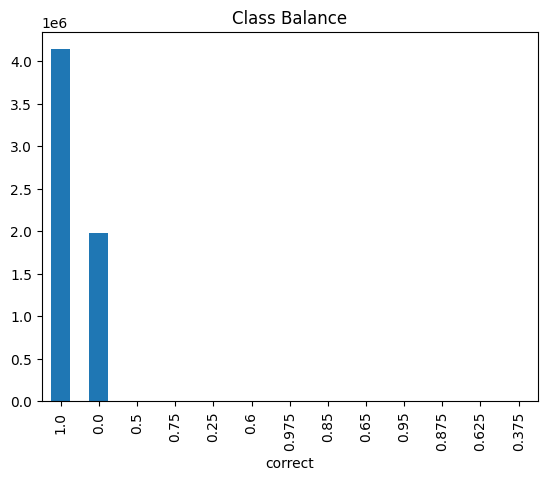

In [7]:
target='correct'
if target in df.columns and df[target].notna().sum()>0:
    counts = df[target].value_counts()
    print(counts)
    print((counts/len(df))*100)
    counts.plot(kind='bar')
    plt.title('Class Balance')
    plt.show()

## Student Activity

count    46674.000000
mean       131.192313
std        232.429192
min          1.000000
25%         16.000000
50%         49.000000
75%        135.000000
max       5562.000000
dtype: float64


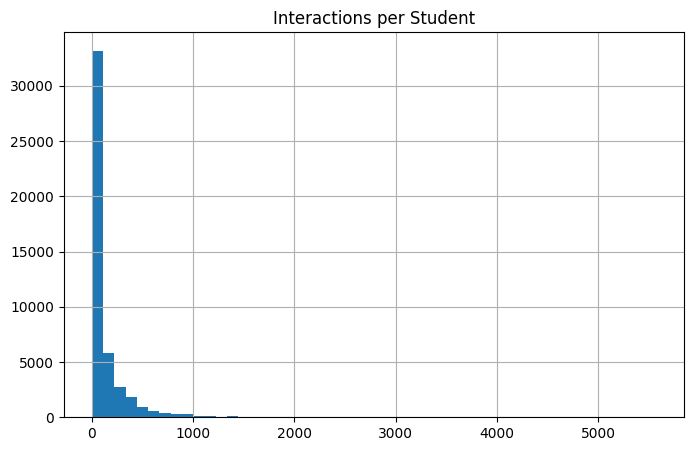

user_id
221054    5562
170143    3698
220012    3551
169527    3480
92113     3292
218757    3157
220017    3024
92806     2829
93581     2799
170998    2709
170982    2707
223010    2538
92677     2466
92709     2462
92804     2438
93678     2398
178828    2390
123162    2354
93549     2323
102088    2294
dtype: int64

In [8]:
student_col = 'user_id'

activity = df.groupby(student_col).size()

print(activity.describe())

activity.hist(bins=50, figsize=(8,5))
plt.title('Interactions per Student')
plt.show()

display(activity.sort_values(ascending=False).head(20))


## Skill Analysis

Unique Skills: 265


skill_id
311.0    192976
277.0    151061
280.0    146992
47.0      98629
279.0     84291
276.0     70453
310.0     67325
67.0      66141
61.0      62715
312.0     59800
79.0      58784
278.0     56145
86.0      46036
83.0      45381
340.0     37157
309.0     35700
54.0      34970
27.0      31335
94.0      30997
49.0      30272
Name: count, dtype: int64

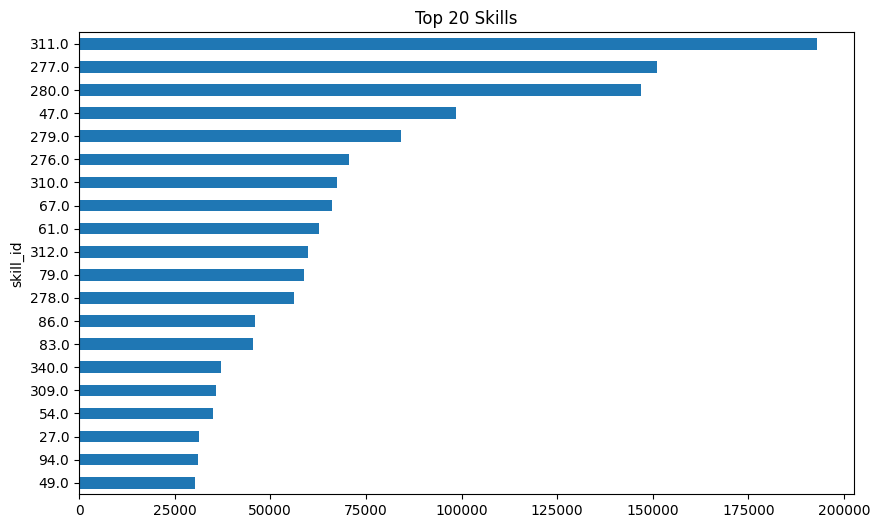

In [9]:
skill_col = 'skill_id'

print('Unique Skills:', df[skill_col].nunique())

top_skills = df[skill_col].value_counts().head(20)

display(top_skills)

top_skills.sort_values().plot(kind='barh', figsize=(10,6))
plt.title('Top 20 Skills')
plt.show()


## Problem Analysis

In [10]:
if 'problem_id' in df.columns:
    print('Unique Problems:', df['problem_id'].nunique())
    display(df['problem_id'].value_counts().head(20))


Unique Problems: 179999


problem_id
432007    3962
416083    3959
431991    3898
432025    3879
416563    3854
437079    3852
273730    3850
437082    3839
432024    3838
416794    3790
416796    3771
437054    3758
273729    3732
439202    3713
416795    3704
273719    3696
439201    3693
273733    3670
457384    3667
457383    3604
Name: count, dtype: int64

## Opportunity Analysis

In [11]:
for col in ['opportunity','Opportunity(Default)']:
    if col in df.columns:
        temp = pd.to_numeric(df[col], errors='coerce')
        print(col)
        print(temp.describe())

        temp.hist(bins=50)
        plt.title(f'{col} Distribution')
        plt.show()


## Sequence Length

count    46674.000000
mean       131.192313
std        232.429192
min          1.000000
25%         16.000000
50%         49.000000
75%        135.000000
max       5562.000000
dtype: float64


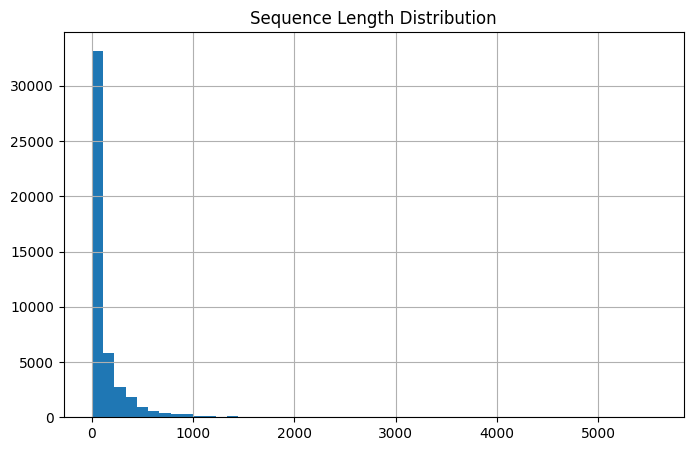

In [12]:
seq_lengths = df.groupby('user_id').size()

print(seq_lengths.describe())

seq_lengths.hist(bins=50, figsize=(8,5))
plt.title('Sequence Length Distribution')
plt.show()


## Response Time


 ms_first_response
count    6.123270e+06
mean     4.873469e+04
std      2.673557e+05
min     -6.767000e+03
25%      9.436000e+03
50%      2.233100e+04
75%      5.486500e+04
max      3.450552e+08
Name: ms_first_response, dtype: float64


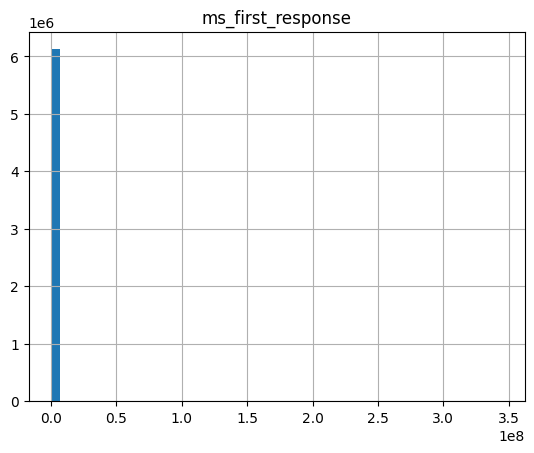

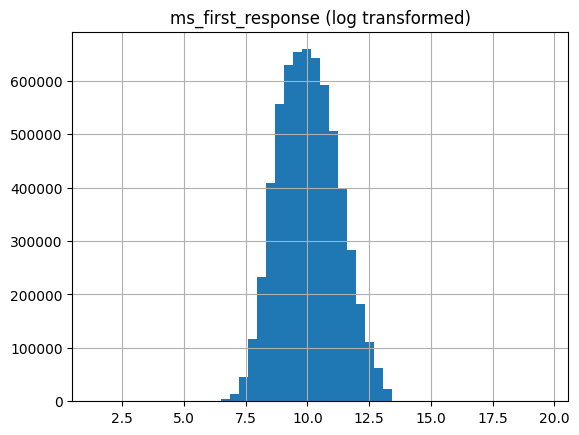


 overlap_time
count    6.123270e+06
mean     4.907237e+04
std      2.884992e+05
min     -6.767000e+03
25%      9.468000e+03
50%      2.241500e+04
75%      5.505400e+04
max      3.452775e+08
Name: overlap_time, dtype: float64


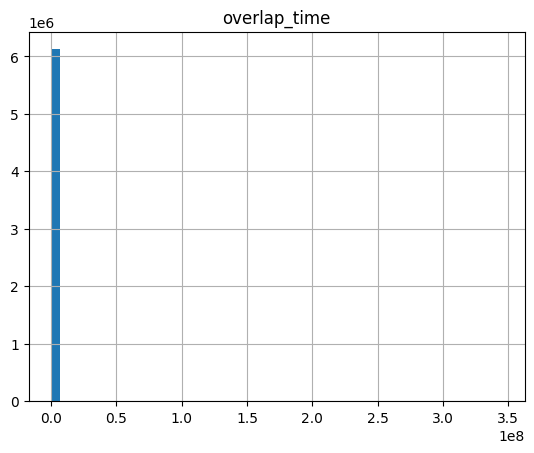

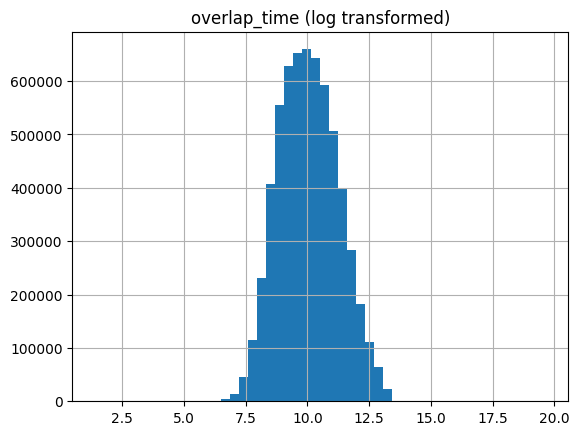

In [13]:
for col in ['ms_first_response','overlap_time']:
    if col in df.columns:
        temp = pd.to_numeric(df[col], errors='coerce')

        print('\n', col)
        print(temp.describe())

        temp.hist(bins=50)
        plt.title(col)
        plt.show()

        np.log1p(temp[temp >= 0]).hist(bins=50)
        plt.title(col + ' (log transformed)')
        plt.show()


## Student Success Rate

count    46674.000000
mean         0.650350
std          0.214418
min          0.000000
25%          0.532084
50%          0.679012
75%          0.800000
max          1.000000
Name: correct, dtype: float64


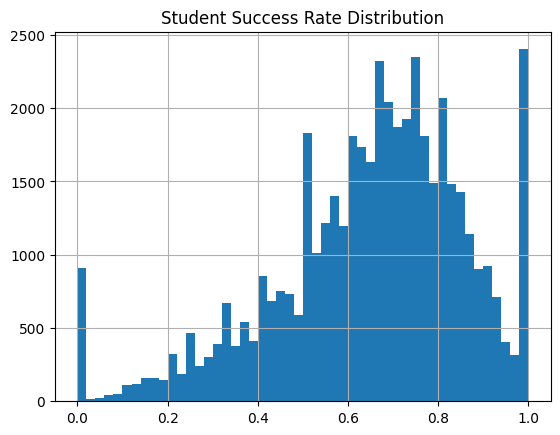

In [14]:
if target is not None:

    success = (
        df.groupby('user_id')[target]
        .mean()
        .sort_values(ascending=False)
    )

    print(success.describe())

    success.hist(bins=50)
    plt.title('Student Success Rate Distribution')
    plt.show()


## Skill Difficulty Analysis

In [15]:
if target is not None and 'skill_id' in df.columns:

    skill_perf = (
        df.groupby('skill_id')[target]
        .mean()
        .sort_values()
    )

    print('Most Difficult Skills')
    display(skill_perf.head(10))

    print('Easiest Skills')
    display(skill_perf.tail(10))


Most Difficult Skills


skill_id
178.0    0.000000
348.0    0.000000
611.0    0.000000
594.0    0.054545
289.0    0.107595
597.0    0.129032
606.0    0.163636
45.0     0.166667
608.0    0.166667
573.0    0.174727
Name: correct, dtype: float64

Easiest Skills


skill_id
52.0     0.876448
51.0     0.877260
600.0    0.891304
283.0    0.892114
577.0    0.895874
32.0     0.930061
174.0    0.941176
601.0    0.960000
391.0    0.979050
291.0    1.000000
Name: correct, dtype: float64

## Correlation Analysis

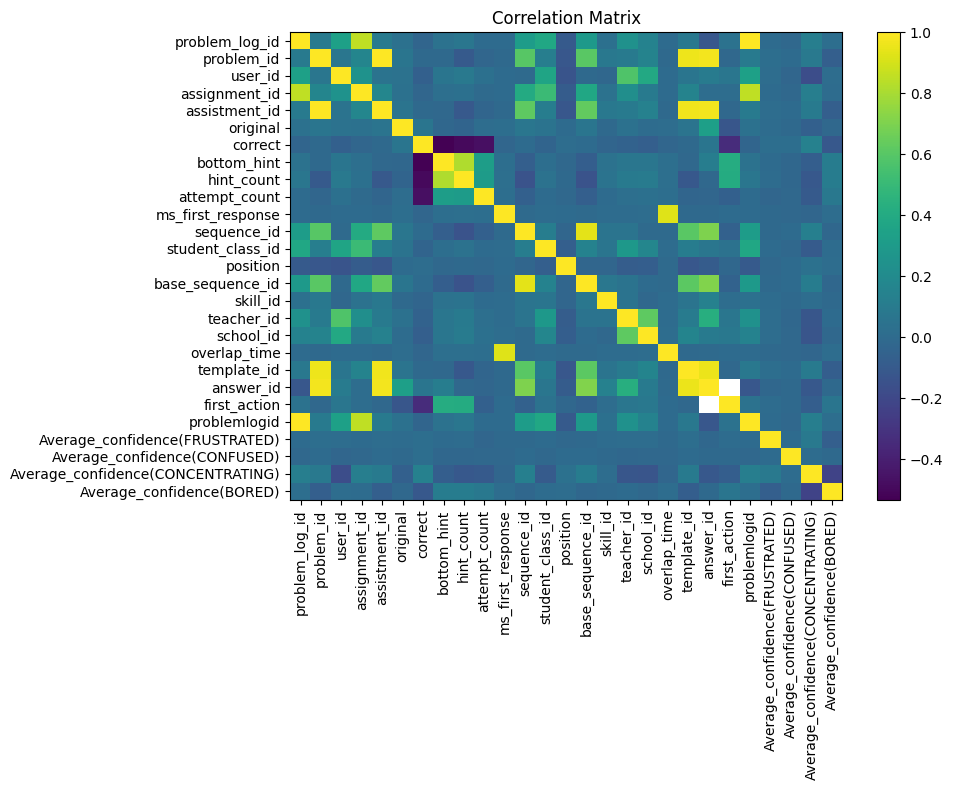

In [16]:
num_cols = df.select_dtypes(include=np.number).columns

if len(num_cols) > 1:

    corr = df[num_cols].corr()

    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.title('Correlation Matrix')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.tight_layout()
    plt.show()


## Key Preprocessing Issues

- Missing skill labels
- Missing opportunity counts
- Class imbalance
- High-cardinality student/problem/skill identifiers
- Uneven student activity levels
- Response-time outliers
- Need for embeddings instead of one-hot encoding
